## K-means clustering

In [1]:
import logging
import pandas as pd
import matplotlib.pyplot as plt

# KMeans maakt clusters
from sklearn.cluster import KMeans

# zet data op dezelfde schaal
from sklearn.preprocessing import StandardScaler

# Silhouette score meet hoe goed de clusters zijn
from sklearn.metrics import silhouette_score

### Logger instellen

In [2]:
# logging instellingen
logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s - %(message)s",
    handlers=[
        # Schrijft log naar een bestand
        logging.FileHandler("clustering_logboek.txt", mode="w", encoding="utf-8"),

        # Toont log berichten in code
        logging.StreamHandler()
    ]
)

# Maakt de logger
logger = logging.getLogger(__name__)
logger.info("Logger gestart")

INFO - Logger gestart


### Dataset inlezen

In [3]:
# Leest de dataset
df = pd.read_excel("AmesHousing.xlsx", sheet_name="AmesHousing")

# Logt aantal rijen en kolommen
logger.info(f"Bestand succesvol ingelezen ({df.shape[0]} rijen, {df.shape[1]} kolommen)")

df.head()

INFO - Bestand succesvol ingelezen (2930 rijen, 12 kolommen)


,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,House Style
0,1,215000,yes,6,1656,1080.0,31770,1960,1,3,NAmes,1Story
1,2,105000,yes,5,896,882.0,11622,1961,1,2,NAmes,1Story
2,3,172000,yes,6,1329,1329.0,14267,1958,1,3,NAmes,1Story
3,4,244000,yes,7,2110,2110.0,11160,1968,2,3,NAmes,1Story
4,5,189900,yes,5,1629,928.0,13830,1997,2,3,Gilbert,2Story


In [4]:
df.dtypes

ID                 int64
SalePrice          int64
Garage               str
Overall Qual       int64
Gr Liv Area        int64
Total Bsmt SF    float64
Lot Area           int64
Year Built         int64
Full Bath          int64
Bedroom AbvGr      int64
Neighborhood         str
House Style          str
dtype: object

### Keuze van top 3 features

Ik kies Overall Qual, Gr Liv Area en Neighborhood als features voor clustering.

- Overall Qual: algemene kwaliteit van het huis
- Gr Liv Area: woonoppervlakte
- Neighborhood: wijk van het huis, dit is de categorische feature

Deze features zijn geschikt, omdat ze de kwaliteit, grootte en ligging van huizen beschrijven.

In [5]:
# Leest de uitleg over de kolommen in
data_dictionary = pd.read_excel("AmesHousing.xlsx", sheet_name="Data Dictionary")

gekozen_features = ["Overall Qual", "Gr Liv Area", "Neighborhood"]

# Filtert alleen de gekozen features
uitleg_features = data_dictionary[data_dictionary["Variabele"].isin(gekozen_features)]

# Logt de gekozen features
logger.info(f"Gekozen top 3 features voor clustering: {gekozen_features}")

uitleg_features

INFO - Gekozen top 3 features voor clustering: ['Overall Qual', 'Gr Liv Area', 'Neighborhood']


,Variabele,Betekenis
3,Overall Qual,Algemene kwaliteit van materialen en afwerking...
4,Gr Liv Area,Woonoppervlak boven de grond (square feet)
10,Neighborhood,Wijk binnen Ames


### Data prepareren

We maken eerst een DataFrame met de gekozen features.
Daarna vullen we missende waarden op, omdat K-means niet met lege waarden kan werken.
Tot slot zetten we de categorische feature Neighborhood om naar dummies: aparte 0/1-kolommen per wijk.

In [6]:
# Selecteert de features
data_stap4 = df[gekozen_features].copy()

# Vult missende waarden
data_stap4 = data_stap4.fillna(0)

# Zet Neighborhood om naar 0/1
data_stap4_encoded = pd.get_dummies(data_stap4, columns=["Neighborhood"])

logger.info(f"One-hot encoding uitgevoerd: {data_stap4_encoded.shape}")

data_stap4_encoded.head()

INFO - One-hot encoding uitgevoerd: (2930, 30)


,Overall Qual,Gr Liv Area,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,6,1656,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,5,896,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,6,1329,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,7,2110,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,1629,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Eerste KMeans-model

Bij K-means is schalen handig, omdat grote waarden anders meer invloed hebben op de afstandsberekening.
Daarom gebruiken we StandardScaler().

Daarna bekijken we met help(KMeans) welke hyperparameters je kunt instellen.

In [7]:
# Schaalt alle features naar vergelijkbare waarden
scaler = StandardScaler()
data_stap5_scaled = scaler.fit_transform(data_stap4_encoded)

logger.info("Data geschaald met StandardScaler")

INFO - Data geschaald met StandardScaler


In [8]:
help(KMeans)

Help on class KMeans in module sklearn.cluster._kmeans:

class KMeans(_BaseKMeans)
 |  KMeans(
 |      n_clusters=8,
 |      *,
 |      init='k-means++',
 |      n_init='auto',
 |      max_iter=300,
 |      tol=0.0001,
 |      verbose=0,
 |      random_state=None,
 |      copy_x=True,
 |      algorithm='lloyd'
 |  )
 |
 |  K-Means clustering.
 |
 |  Read more in the :ref:`User Guide <k_means>`.
 |
 |  Parameters
 |  ----------
 |
 |  n_clusters : int, default=8
 |      The number of clusters to form as well as the number of
 |      centroids to generate.
 |
 |      For an example of how to choose an optimal value for `n_clusters` refer to
 |      :ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.
 |
 |  init : {'k-means++', 'random'}, callable or array-like of shape             (n_clusters, n_features), default='k-means++'
 |      Method for initialization:
 |
 |      * 'k-means++' : selects initial cluster centroids using sampling             based on an empiric

### Eerste model

Voor de eerste run kies ik:
- n_clusters = 4 -> 28 elleboog methode
- random_state = 42
- n_init = 10

n_clusters bepaalt het aantal clusters.
Met n_init probeert K-means meerdere beginpunten en kiest het de beste oplossing.

In [9]:
kmeans_1 = KMeans(n_clusters=28, random_state=42, n_init=10)

# Traint KMeans en geeft per huis het cluster terug
labels_1 = kmeans_1.fit_predict(data_stap5_scaled)

# Voegt de cluster labels toe aan de originele data
resultaat_1 = data_stap4.copy()
resultaat_1["Cluster"] = labels_1

logger.info("Eerste KMeans-model getraind: n_clusters=28, random_state=42, n_init=10")

resultaat_1.head()

INFO - Eerste KMeans-model getraind: n_clusters=28, random_state=42, n_init=10


,Overall Qual,Gr Liv Area,Neighborhood,Cluster
0,6,1656,NAmes,4
1,5,896,NAmes,4
2,6,1329,NAmes,4
3,7,2110,NAmes,4
4,5,1629,Gilbert,0


## Evaluatie van het eerste model

We evalueren het model met:
- Inertia / WSS: laat zien hoe dicht de punten bij hun eigen clustercentrum liggen. Lager is meestal beter.
- Silhouette score: laat zien hoe goed de clusters van elkaar gescheiden zijn. Hoger is meestal beter.

Daarnaast bekijken we hoeveel huizen er in elk cluster zitten.

In [10]:
# Haalt de foutscore van het model op
inertia_1 = kmeans_1.inertia_

# Meet hoe goed de clusters van elkaar gescheiden zijn
silhouette_1 = silhouette_score(data_stap5_scaled, labels_1)

# Telt hoeveel huizen er in elk cluster zitten
cluster_verdeling_1 = resultaat_1["Cluster"].value_counts().sort_index()

print(f"Inertia / WSS: {inertia_1:.2f}")
print(f"Silhouette score: {silhouette_1:.4f}")
print("\nVerdeling per cluster:")
print(cluster_verdeling_1)

logger.info(f"Eerste model - inertia: {inertia_1:.2f}, silhouette: {silhouette_1:.4f}")
logger.info(f"Clusterverdeling: {cluster_verdeling_1.to_dict()}")

INFO - Eerste model - inertia: 3434.21, silhouette: 0.7799
INFO - Clusterverdeling: {0: 165, 1: 194, 2: 239, 3: 182, 4: 443, 5: 166, 6: 131, 7: 71, 8: 267, 9: 103, 10: 125, 11: 93, 12: 108, 13: 114, 14: 44, 15: 151, 16: 28, 17: 51, 18: 37, 19: 30, 20: 72, 21: 48, 22: 8, 23: 2, 24: 23, 25: 24, 26: 10, 27: 1}


Inertia / WSS: 3434.21
Silhouette score: 0.7799

Verdeling per cluster:
Cluster
0     165
1     194
2     239
3     182
4     443
5     166
6     131
7      71
8     267
9     103
10    125
11     93
12    108
13    114
14     44
15    151
16     28
17     51
18     37
19     30
20     72
21     48
22      8
23      2
24     23
25     24
26     10
27      1
Name: count, dtype: int64


### Korte interpretatie

- Lagere inertia = huizen binnen een cluster lijken meer op elkaar.
- Hogere silhouette score = clusters zijn beter van elkaar gescheiden.

De silhouette score is vaak het handigst om experimenten te vergelijken.

## Elleboogmethode

Bij de elleboogmethode testen we meerdere waarden voor `k`.
Daarna kijken we waar de lijn van de inertia/WSS begint af te vlakken.
Dat is vaak een goed aantal clusters.

INFO - Elleboogmethode uitgevoerd voor k = 2 t/m 34


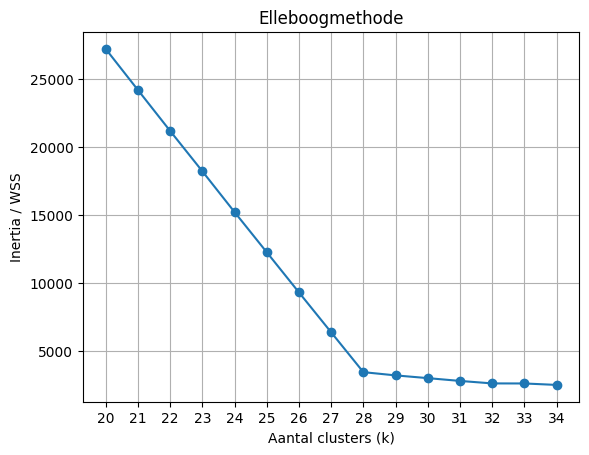

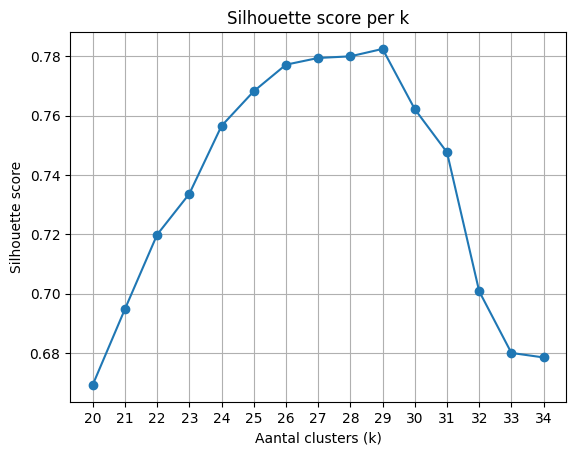

In [30]:
# Test meerdere aantallen clusters om te zien welke k logisch is
# We starten bij 2, omdat silhouette_score minimaal 2 clusters nodig heeft.
k_waardes = range(20, 35)
wss_scores = []
silhouette_scores = []

for k in k_waardes:
    # Train voor elke k een nieuw KMeans-model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(data_stap5_scaled)

    # Inertia/WSS: lager betekent compactere clusters
    wss_scores.append(kmeans.inertia_)

    # Silhouette: hoger betekent meestal beter gescheiden clusters
    silhouette_scores.append(silhouette_score(data_stap5_scaled, labels))

logger.info("Elleboogmethode uitgevoerd voor k = 2 t/m 34")

# Tekent de ellebooggrafiek
# Het beste k-punt ligt vaak waar de daling minder sterk wordt.
plt.plot(list(k_waardes), wss_scores, marker="o")
plt.xlabel("Aantal clusters (k)")
plt.ylabel("Inertia / WSS")
plt.title("Elleboogmethode")
plt.xticks(list(k_waardes))
plt.grid(True)
plt.show()

# Extra controle: silhouette score per k
plt.plot(list(k_waardes), silhouette_scores, marker="o")
plt.xlabel("Aantal clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score per k")
plt.xticks(list(k_waardes))
plt.grid(True)
plt.show()

## Experimenteren

Hieronder staan meerdere experimenten.
Per experiment noteren we:
- gekozen features,
- categorische features,
- of er geschaald is,
- hyperparameters,
- inertia,
- silhouette score.

We bewaren alle werkende experimenten, zodat de ontwikkeling van het model zichtbaar blijft.

In [12]:
# Maakt een lijst om de resultaten van experimenten op te slaan
experiment_resultaten = []

# Slaat de instellingen en scores van de eerste clustering-run op
experiment_resultaten.append({
    "Experiment": "Initiële run",
    "Features": ", ".join(gekozen_features),
    "Categorische feature": "Neighborhood",
    "Geschaald": "Ja",
    "n_clusters": 28,
    "random_state": 42,
    "n_init": 10,
    "Inertia": round(inertia_1, 2),
    "Silhouette score": round(silhouette_1, 4)
})

### Experiment 1 – Zelfde features, maar ander aantal clusters

In [13]:
# Gebruikt dezelfde features, maar test nu met 5 clusters
features_exp1 = ["Overall Qual", "Gr Liv Area", "Neighborhood"]
data_exp1 = df[features_exp1].copy()

# Vult missende waarden op voor KMeans
data_exp1 = data_exp1.fillna(0)

# Zet de categorische kolom Neighborhood om naar numerieke 0/1
data_exp1_encoded = pd.get_dummies(data_exp1, columns=["Neighborhood"])

# Schaalt de data zodat geen feature te zwaar meetelt
scaler_exp1 = StandardScaler()
data_exp1_scaled = scaler_exp1.fit_transform(data_exp1_encoded)

# Traint KMeans met 5 clusters
kmeans_exp1 = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_exp1 = kmeans_exp1.fit_predict(data_exp1_scaled)

# Berekent de kwaliteit van de clustering
inertia_exp1 = kmeans_exp1.inertia_
silhouette_exp1 = silhouette_score(data_exp1_scaled, labels_exp1)

print(f"Inertia / WSS: {inertia_exp1:.2f}")
print(f"Silhouette score: {silhouette_exp1:.4f}")

logger.info("Experiment 1 uitgevoerd: n_clusters=5, random_state=42, n_init=10")
logger.info(f"Experiment 1 - features: {features_exp1}")
logger.info(f"Experiment 1 - inertia: {inertia_exp1:.2f}, silhouette: {silhouette_exp1:.4f}")

# Slaat de instellingen en scores van dit experiment op
experiment_resultaten.append({
    "Experiment": "Experiment 1 - ander aantal clusters",
    "Features": ", ".join(features_exp1),
    "Categorische feature": "Neighborhood",
    "Geschaald": "Ja",
    "n_clusters": 5,
    "random_state": 42,
    "n_init": 10,
    "Inertia": round(inertia_exp1, 2),
    "Silhouette score": round(silhouette_exp1, 4)
})

INFO - Experiment 1 uitgevoerd: n_clusters=5, random_state=42, n_init=10
INFO - Experiment 1 - features: ['Overall Qual', 'Gr Liv Area', 'Neighborhood']
INFO - Experiment 1 - inertia: 73747.00, silhouette: 0.1597


Inertia / WSS: 73747.00
Silhouette score: 0.1597


### Experiment 2 – Meer features toevoegen

In [14]:
# Experiment 2: voeg Total Bsmt SF toe als extra feature
features_exp2 = ["Overall Qual", "Gr Liv Area", "Total Bsmt SF", "Neighborhood"]
data_exp2 = df[features_exp2].copy()

# Vult missende waarden op voor KMeans
data_exp2 = data_exp2.fillna(0)

# Zet Neighborhood om naar numerieke 0/1
data_exp2_encoded = pd.get_dummies(data_exp2, columns=["Neighborhood"])

# Schaalt alle features naar dezelfde schaal
scaler_exp2 = StandardScaler()
data_exp2_scaled = scaler_exp2.fit_transform(data_exp2_encoded)

# Traint KMeans met 4 clusters
kmeans_exp2 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_exp2 = kmeans_exp2.fit_predict(data_exp2_scaled)

# Berekent de kwaliteit van de clustering
inertia_exp2 = kmeans_exp2.inertia_
silhouette_exp2 = silhouette_score(data_exp2_scaled, labels_exp2)

print(f"Inertia / WSS: {inertia_exp2:.2f}")
print(f"Silhouette score: {silhouette_exp2:.4f}")

logger.info("Experiment 2 uitgevoerd: n_clusters=4, random_state=42, n_init=10")
logger.info(f"Experiment 2 - features: {features_exp2}")
logger.info(f"Experiment 2 - inertia: {inertia_exp2:.2f}, silhouette: {silhouette_exp2:.4f}")

# Slaat de instellingen en scores van experiment 2 op
experiment_resultaten.append({
    "Experiment": "Experiment 2 - extra feature",
    "Features": ", ".join(features_exp2),
    "Categorische feature": "Neighborhood",
    "Geschaald": "Ja",
    "n_clusters": 4,
    "random_state": 42,
    "n_init": 10,
    "Inertia": round(inertia_exp2, 2),
    "Silhouette score": round(silhouette_exp2, 4)
})

INFO - Experiment 2 uitgevoerd: n_clusters=4, random_state=42, n_init=10
INFO - Experiment 2 - features: ['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Neighborhood']
INFO - Experiment 2 - inertia: 79028.12, silhouette: 0.1333


Inertia / WSS: 79028.12
Silhouette score: 0.1333


### Experiment 3 – Andere categorische feature


In [15]:
# Experiment 3: gebruik House Style als categorische feature
features_exp3 = ["Overall Qual", "Gr Liv Area", "House Style"]
data_exp3 = df[features_exp3].copy()

# Vult missende waarden op voor KMeans
data_exp3 = data_exp3.fillna(0)

# Zet House Style om naar numerieke 0/1
data_exp3_encoded = pd.get_dummies(data_exp3, columns=["House Style"])

# Schaalt alle features naar dezelfde schaal
scaler_exp3 = StandardScaler()
data_exp3_scaled = scaler_exp3.fit_transform(data_exp3_encoded)

# Traint KMeans met 4 clusters
kmeans_exp3 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_exp3 = kmeans_exp3.fit_predict(data_exp3_scaled)

# Berekent de kwaliteit van de clustering
inertia_exp3 = kmeans_exp3.inertia_
silhouette_exp3 = silhouette_score(data_exp3_scaled, labels_exp3)

print(f"Inertia / WSS: {inertia_exp3:.2f}")
print(f"Silhouette score: {silhouette_exp3:.4f}")

logger.info("Experiment 3 uitgevoerd: n_clusters=4, random_state=42, n_init=10")
logger.info(f"Experiment 3 - features: {features_exp3}")
logger.info(f"Experiment 3 - inertia: {inertia_exp3:.2f}, silhouette: {silhouette_exp3:.4f}")

# Slaat de instellingen en scores van experiment 3 op
experiment_resultaten.append({
    "Experiment": "Experiment 3 - andere categorische feature",
    "Features": ", ".join(features_exp3),
    "Categorische feature": "House Style",
    "Geschaald": "Ja",
    "n_clusters": 4,
    "random_state": 42,
    "n_init": 10,
    "Inertia": round(inertia_exp3, 2),
    "Silhouette score": round(silhouette_exp3, 4)
})

INFO - Experiment 3 uitgevoerd: n_clusters=4, random_state=42, n_init=10
INFO - Experiment 3 - features: ['Overall Qual', 'Gr Liv Area', 'House Style']
INFO - Experiment 3 - inertia: 16853.19, silhouette: 0.5094


Inertia / WSS: 16853.19
Silhouette score: 0.5094


### Experiment 4 – Meer features, ander aantal clusters en andere hyperparameter

In [16]:
# Experiment 4: test meer features, 5 clusters en hogere n_init
features_exp4 = ["Overall Qual", "Gr Liv Area", "Total Bsmt SF", "Year Built", "Neighborhood"]
data_exp4 = df[features_exp4].copy()

# Vult missende waarden op voor KMeans
data_exp4 = data_exp4.fillna(0)

# Zet Neighborhood om naar numerieke 0/1
data_exp4_encoded = pd.get_dummies(data_exp4, columns=["Neighborhood"])

# Schaalt alle features naar dezelfde schaal
scaler_exp4 = StandardScaler()
data_exp4_scaled = scaler_exp4.fit_transform(data_exp4_encoded)

# Traint KMeans met 5 clusters en 20 initialisaties
kmeans_exp4 = KMeans(n_clusters=5, random_state=42, n_init=20)
labels_exp4 = kmeans_exp4.fit_predict(data_exp4_scaled)

# Berekent de clustering-scores
inertia_exp4 = kmeans_exp4.inertia_
silhouette_exp4 = silhouette_score(data_exp4_scaled, labels_exp4)

print(f"Inertia / WSS: {inertia_exp4:.2f}")
print(f"Silhouette score: {silhouette_exp4:.4f}")

logger.info("Experiment 4 uitgevoerd: n_clusters=5, random_state=42, n_init=20")
logger.info(f"Experiment 4 - features: {features_exp4}")
logger.info(f"Experiment 4 - inertia: {inertia_exp4:.2f}, silhouette: {silhouette_exp4:.4f}")

# Slaat de instellingen en scores van experiment 4 op
experiment_resultaten.append({
    "Experiment": "Experiment 4 - meer features en ander k",
    "Features": ", ".join(features_exp4),
    "Categorische feature": "Neighborhood",
    "Geschaald": "Ja",
    "n_clusters": 5,
    "random_state": 42,
    "n_init": 20,
    "Inertia": round(inertia_exp4, 2),
    "Silhouette score": round(silhouette_exp4, 4)
})

INFO - Experiment 4 uitgevoerd: n_clusters=5, random_state=42, n_init=20
INFO - Experiment 4 - features: ['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Year Built', 'Neighborhood']
INFO - Experiment 4 - inertia: 76814.43, silhouette: 0.1234


Inertia / WSS: 76814.43
Silhouette score: 0.1234


### Extra experimenten

In [17]:
def voer_kmeans_experiment_uit(
    naam,
    features,
    categorische_features=None,
    n_clusters=4,
    n_init=10,
    schaal=True,
    random_state=42
):

    if categorische_features is None:
        categorische_features = []

    data_exp = df[features].copy()

    numerieke_features = [kolom for kolom in features if kolom not in categorische_features]

    for kolom in numerieke_features:
        data_exp[kolom] = data_exp[kolom].fillna(data_exp[kolom].median())

    for kolom in categorische_features:
        data_exp[kolom] = data_exp[kolom].fillna("Onbekend")

    if len(categorische_features) > 0:
        data_exp_encoded = pd.get_dummies(data_exp, columns=categorische_features)
    else:
        data_exp_encoded = data_exp.copy()

    if schaal:
        scaler_exp = StandardScaler()
        data_exp_model = scaler_exp.fit_transform(data_exp_encoded)
        geschaald = "Ja"
    else:
        data_exp_model = data_exp_encoded
        geschaald = "Nee"

    kmeans_exp = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=n_init)
    labels_exp = kmeans_exp.fit_predict(data_exp_model)

    inertia_exp = kmeans_exp.inertia_
    silhouette_exp = silhouette_score(data_exp_model, labels_exp)

    print(f"{naam}")
    print(f"Features: {features}")
    print(f"Categorische features: {categorische_features if categorische_features else 'Geen'}")
    print(f"n_clusters: {n_clusters}")
    print(f"Geschaald: {geschaald}")
    print(f"Inertia / WSS: {inertia_exp:.2f}")
    print(f"Silhouette score: {silhouette_exp:.4f}")

    logger.info(
        f"{naam} uitgevoerd: features={features}, categorische_features={categorische_features}, "
        f"n_clusters={n_clusters}, n_init={n_init}, schaal={geschaald}, "
        f"inertia={inertia_exp:.2f}, silhouette={silhouette_exp:.4f}"
    )

    experiment_resultaten.append({
        "Experiment": naam,
        "Features": ", ".join(features),
        "Categorische feature": ", ".join(categorische_features) if categorische_features else "Geen",
        "Geschaald": geschaald,
        "n_clusters": n_clusters,
        "random_state": random_state,
        "n_init": n_init,
        "Inertia": round(inertia_exp, 2),
        "Silhouette score": round(silhouette_exp, 4)
    })

    return kmeans_exp, labels_exp, data_exp_encoded

In [18]:
model_exp5, labels_exp5, data_exp5_encoded = voer_kmeans_experiment_uit(
    naam="Experiment 5 - alleen numerieke basisfeatures",
    features=["Overall Qual", "Gr Liv Area", "Total Bsmt SF"],
    categorische_features=[],
    n_clusters=3,
    n_init=10,
    schaal=True
)

INFO - Experiment 5 - alleen numerieke basisfeatures uitgevoerd: features=['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF'], categorische_features=[], n_clusters=3, n_init=10, schaal=Ja, inertia=4107.18, silhouette=0.2944


Experiment 5 - alleen numerieke basisfeatures
Features: ['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF']
Categorische features: Geen
n_clusters: 3
Geschaald: Ja
Inertia / WSS: 4107.18
Silhouette score: 0.2944


In [19]:
model_exp6, labels_exp6, data_exp6_encoded = voer_kmeans_experiment_uit(
    naam="Experiment 6 - meer numerieke features",
    features=["Overall Qual", "Gr Liv Area", "Total Bsmt SF", "Year Built", "Full Bath", "Bedroom AbvGr"],
    categorische_features=[],
    n_clusters=4,
    n_init=10,
    schaal=True
)

INFO - Experiment 6 - meer numerieke features uitgevoerd: features=['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Year Built', 'Full Bath', 'Bedroom AbvGr'], categorische_features=[], n_clusters=4, n_init=10, schaal=Ja, inertia=8344.84, silhouette=0.2820


Experiment 6 - meer numerieke features
Features: ['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Year Built', 'Full Bath', 'Bedroom AbvGr']
Categorische features: Geen
n_clusters: 4
Geschaald: Ja
Inertia / WSS: 8344.84
Silhouette score: 0.2820


In [20]:
model_exp7, labels_exp7, data_exp7_encoded = voer_kmeans_experiment_uit(
    naam="Experiment 7 - garage wel of niet aanwezig",
    features=["Overall Qual", "Gr Liv Area", "Garage"],
    categorische_features=["Garage"],
    n_clusters=4,
    n_init=10,
    schaal=True
)

INFO - Experiment 7 - garage wel of niet aanwezig uitgevoerd: features=['Overall Qual', 'Gr Liv Area', 'Garage'], categorische_features=['Garage'], n_clusters=4, n_init=10, schaal=Ja, inertia=2193.51, silhouette=0.4062


Experiment 7 - garage wel of niet aanwezig
Features: ['Overall Qual', 'Gr Liv Area', 'Garage']
Categorische features: ['Garage']
n_clusters: 4
Geschaald: Ja
Inertia / WSS: 2193.51
Silhouette score: 0.4062


In [21]:
model_exp8, labels_exp8, data_exp8_encoded = voer_kmeans_experiment_uit(
    naam="Experiment 8 - wijk en garage gecombineerd",
    features=["Overall Qual", "Gr Liv Area", "Neighborhood", "Garage"],
    categorische_features=["Neighborhood", "Garage"],
    n_clusters=6,
    n_init=10,
    schaal=True
)

INFO - Experiment 8 - wijk en garage gecombineerd uitgevoerd: features=['Overall Qual', 'Gr Liv Area', 'Neighborhood', 'Garage'], categorische_features=['Neighborhood', 'Garage'], n_clusters=6, n_init=10, schaal=Ja, inertia=73752.77, silhouette=0.1969


Experiment 8 - wijk en garage gecombineerd
Features: ['Overall Qual', 'Gr Liv Area', 'Neighborhood', 'Garage']
Categorische features: ['Neighborhood', 'Garage']
n_clusters: 6
Geschaald: Ja
Inertia / WSS: 73752.77
Silhouette score: 0.1969


In [22]:
model_exp9, labels_exp9, data_exp9_encoded = voer_kmeans_experiment_uit(
    naam="Experiment 9 - prijssegmenten met SalePrice",
    features=["SalePrice", "Overall Qual", "Gr Liv Area", "Neighborhood"],
    categorische_features=["Neighborhood"],
    n_clusters=5,
    n_init=10,
    schaal=True
)

INFO - Experiment 9 - prijssegmenten met SalePrice uitgevoerd: features=['SalePrice', 'Overall Qual', 'Gr Liv Area', 'Neighborhood'], categorische_features=['Neighborhood'], n_clusters=5, n_init=10, schaal=Ja, inertia=75127.09, silhouette=0.1298


Experiment 9 - prijssegmenten met SalePrice
Features: ['SalePrice', 'Overall Qual', 'Gr Liv Area', 'Neighborhood']
Categorische features: ['Neighborhood']
n_clusters: 5
Geschaald: Ja
Inertia / WSS: 75127.09
Silhouette score: 0.1298


In [23]:
model_exp10, labels_exp10, data_exp10_encoded = voer_kmeans_experiment_uit(
    naam="Experiment 10 - zonder StandardScaler",
    features=["Overall Qual", "Gr Liv Area", "Total Bsmt SF", "Lot Area"],
    categorische_features=[],
    n_clusters=5,
    n_init=10,
    schaal=False
)

INFO - Experiment 10 - zonder StandardScaler uitgevoerd: features=['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Lot Area'], categorische_features=[], n_clusters=5, n_init=10, schaal=Nee, inertia=19868966055.60, silhouette=0.4889


Experiment 10 - zonder StandardScaler
Features: ['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Lot Area']
Categorische features: Geen
n_clusters: 5
Geschaald: Nee
Inertia / WSS: 19868966055.60
Silhouette score: 0.4889


In [24]:
model_exp11, labels_exp11, data_exp11_encoded = voer_kmeans_experiment_uit(
    naam="Experiment 11 - basisfeatures met 8 clusters",
    features=["Overall Qual", "Gr Liv Area", "Neighborhood"],
    categorische_features=["Neighborhood"],
    n_clusters=8,
    n_init=10,
    schaal=True
)

INFO - Experiment 11 - basisfeatures met 8 clusters uitgevoerd: features=['Overall Qual', 'Gr Liv Area', 'Neighborhood'], categorische_features=['Neighborhood'], n_clusters=8, n_init=10, schaal=Ja, inertia=64488.20, silhouette=0.2476


Experiment 11 - basisfeatures met 8 clusters
Features: ['Overall Qual', 'Gr Liv Area', 'Neighborhood']
Categorische features: ['Neighborhood']
n_clusters: 8
Geschaald: Ja
Inertia / WSS: 64488.20
Silhouette score: 0.2476


In [25]:
model_exp12, labels_exp12, data_exp12_encoded = voer_kmeans_experiment_uit(
    naam="Experiment 12 - uitgebreide features met 3 clusters",
    features=["Overall Qual", "Gr Liv Area", "Total Bsmt SF", "Year Built", "Neighborhood"],
    categorische_features=["Neighborhood"],
    n_clusters=3,
    n_init=20,
    schaal=True
)

INFO - Experiment 12 - uitgebreide features met 3 clusters uitgevoerd: features=['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Year Built', 'Neighborhood'], categorische_features=['Neighborhood'], n_clusters=3, n_init=20, schaal=Ja, inertia=83320.07, silhouette=0.1131


Experiment 12 - uitgebreide features met 3 clusters
Features: ['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Year Built', 'Neighborhood']
Categorische features: ['Neighborhood']
n_clusters: 3
Geschaald: Ja
Inertia / WSS: 83320.07
Silhouette score: 0.1131


In [26]:
model_exp13, labels_exp13, data_exp13_encoded = voer_kmeans_experiment_uit(
    naam="Experiment 13 - met Lot Area",
    features=["Overall Qual", "Gr Liv Area", "Total Bsmt SF", "Lot Area", "Neighborhood"],
    categorische_features=["Neighborhood"],
    n_clusters=5,
    n_init=20,
    schaal=True
)

INFO - Experiment 13 - met Lot Area uitgevoerd: features=['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Lot Area', 'Neighborhood'], categorische_features=['Neighborhood'], n_clusters=5, n_init=20, schaal=Ja, inertia=78571.22, silhouette=0.0973


Experiment 13 - met Lot Area
Features: ['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Lot Area', 'Neighborhood']
Categorische features: ['Neighborhood']
n_clusters: 5
Geschaald: Ja
Inertia / WSS: 78571.22
Silhouette score: 0.0973


In [27]:
model_exp14, labels_exp14, data_exp14_encoded = voer_kmeans_experiment_uit(
    naam="Experiment 14 - huisstijl garage en kamers",
    features=["Overall Qual", "Gr Liv Area", "Full Bath", "Bedroom AbvGr", "House Style", "Garage"],
    categorische_features=["House Style", "Garage"],
    n_clusters=5,
    n_init=20,
    schaal=True
)

INFO - Experiment 14 - huisstijl garage en kamers uitgevoerd: features=['Overall Qual', 'Gr Liv Area', 'Full Bath', 'Bedroom AbvGr', 'House Style', 'Garage'], categorische_features=['House Style', 'Garage'], n_clusters=5, n_init=20, schaal=Ja, inertia=22535.58, silhouette=0.3639


Experiment 14 - huisstijl garage en kamers
Features: ['Overall Qual', 'Gr Liv Area', 'Full Bath', 'Bedroom AbvGr', 'House Style', 'Garage']
Categorische features: ['House Style', 'Garage']
n_clusters: 5
Geschaald: Ja
Inertia / WSS: 22535.58
Silhouette score: 0.3639


### Vergelijking van alle experimenten

Hier zetten we alle resultaten naast elkaar.
Voor de eindkeuze kijk ik vooral naar de **silhouette score** en naar hoe logisch en duidelijk de gebruikte features zijn.

In [28]:
vergelijking_df = pd.DataFrame(experiment_resultaten)
vergelijking_df = vergelijking_df.sort_values("Silhouette score", ascending=False)
vergelijking_df

,Experiment,Features,Categorische feature,Geschaald,n_clusters,random_state,n_init,Inertia,Silhouette score
0,Initiële run,"Overall Qual, Gr Liv Area, Neighborhood",Neighborhood,Ja,28,42,10,3.434210e+03,0.7799
3,Experiment 3 - andere categorische feature,"Overall Qual, Gr Liv Area, House Style",House Style,Ja,4,42,10,1.685319e+04,0.5094
10,Experiment 10 - zonder StandardScaler,"Overall Qual, Gr Liv Area, Total Bsmt SF, Lot ...",Geen,Nee,5,42,10,1.986897e+10,0.4889
7,Experiment 7 - garage wel of niet aanwezig,"Overall Qual, Gr Liv Area, Garage",Garage,Ja,4,42,10,2.193510e+03,0.4062
14,Experiment 14 - huisstijl garage en kamers,"Overall Qual, Gr Liv Area, Full Bath, Bedroom ...","House Style, Garage",Ja,5,42,20,2.253558e+04,0.3639
5,Experiment 5 - alleen numerieke basisfeatures,"Overall Qual, Gr Liv Area, Total Bsmt SF",Geen,Ja,3,42,10,4.107180e+03,0.2944
6,Experiment 6 - meer numerieke features,"Overall Qual, Gr Liv Area, Total Bsmt SF, Year...",Geen,Ja,4,42,10,8.344840e+03,0.2820
11,Experiment 11 - basisfeatures met 8 clusters,"Overall Qual, Gr Liv Area, Neighborhood",Neighborhood,Ja,8,42,10,6.448820e+04,0.2476
8,Experiment 8 - wijk en garage gecombineerd,"Overall Qual, Gr Liv Area, Neighborhood, Garage","Neighborhood, Garage",Ja,6,42,10,7.375277e+04,0.1969
1,Experiment 1 - ander aantal clusters,"Overall Qual, Gr Liv Area, Neighborhood",Neighborhood,Ja,5,42,10,7.374700e+04,0.1597


In [29]:
beste_experiment = vergelijking_df.iloc[0]

print("Beste experiment op basis van de silhouette score:")
print(beste_experiment[["Experiment", "Silhouette score", "n_clusters"]])

logger.info(
    f"Beste experiment: {beste_experiment['Experiment']} "
    f"(silhouette score = {beste_experiment['Silhouette score']}, "
    f"n_clusters = {beste_experiment['n_clusters']})"
)

INFO - Beste experiment: Initiële run (silhouette score = 0.7799, n_clusters = 28)


Beste experiment op basis van de silhouette score:
Experiment          Initiële run
Silhouette score          0.7799
n_clusters                    28
Name: 0, dtype: object


### Korte conclusie

Het beste experiment is het experiment met de hoogste **silhouette score**.
Dat experiment presteert beter dan de initiële run, omdat de clusters daarin duidelijker van elkaar gescheiden zijn.

Bij de verantwoording kun je dus uitleggen:
1. welke eerste keuze je maakte,
2. welk resultaat daaruit kwam,
3. welk nieuw experiment je daarna probeerde,
4. en waarom dat nieuwe experiment beter of juist minder goed werkte.